# M11.3 — Optimal vs realized matched-filter SNR

## Objective

The M10 synthetic pipeline controls the **optimal matched-filter SNR** of the injected signal.

For detector $I$,

$$
\rho_{I,\mathrm{opt}}^2
=
(h_I|h_I),
$$

where the noise-weighted inner product is

$$
(a|b)
=
4\,\mathrm{Re}
\int_{f_{\mathrm{low}}}^{\infty}
\frac{\tilde a^*(f)\tilde b(f)}
{S_n(f)}
\,df.
$$

The network optimal SNR is

$$
\rho_{\mathrm{net,opt}}
=
\sqrt{
\sum_I
\rho_{I,\mathrm{opt}}^2
}.
$$

However, after adding a specific noise realization,

$$
x_I = h_I+n_I,
$$

the SNR measured against the true template is no longer exactly equal to
$\rho_{I,\mathrm{opt}}$.

M11.3 studies this distinction explicitly before deciding whether additional SNR metadata or changes to the simulation policy are required.

## 1. Definition of realized SNR

In this notebook, **realized SNR** refers to the signed fixed-template matched-filter projection evaluated using the exact injected signal:

$$
\rho_{I,\mathrm{real}}
=
\frac{(x_I|h_I)}
{\sqrt{(h_I|h_I)}}.
$$

Since

$$
x_I=h_I+n_I,
$$

we obtain

$$
\rho_{I,\mathrm{real}}
=
\rho_{I,\mathrm{opt}}
+
\frac{(n_I|h_I)}
{\sqrt{(h_I|h_I)}}.
$$

For stationary Gaussian noise generated from the same PSD used in the inner product,

$$
E[\rho_{I,\mathrm{real}}]
=
\rho_{I,\mathrm{opt}},
$$

and approximately

$$
\mathrm{Var}
\left(
\rho_{I,\mathrm{real}}
-
\rho_{I,\mathrm{opt}}
\right)
\simeq 1.
$$

For the detector network we define the coherent fixed-template projection

$$
\rho_{\mathrm{net,real}}
=
\frac{
\sum_I (x_I|h_I)
}{
\sqrt{
\sum_I(h_I|h_I)
}
}.
$$

Under independent Gaussian detector noise,

$$
\rho_{\mathrm{net,real}}
-
\rho_{\mathrm{net,opt}}
\sim
\mathcal N(0,1)
$$

approximately.

This quantity must not be confused with a phase-maximized search SNR, the maximum of a matched-filter time series, or a reweighted detection statistic.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm

PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import SimulationConfig
from src.parameters import CBCParameters
from src.dataset import DatasetBuilder
from src.snr import (
    compute_detector_optimal_snr,
    compute_network_optimal_snr,
    rescale_distance_for_target_network_snr,
)

/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pycbc/waveform/plugin.py:99: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

## 2. Controlled simulation setup

M11.3-A isolates only the statistical distinction between optimal and realized SNR.

Therefore:

- the waveform model is unchanged;
- detector geometry is fixed;
- the same analytical PSDs used by the Gaussian M10 noise model are retained;
- the final analysis segment remains 4 s;
- no processed CNN input is involved yet;
- no input z-score is applied;
- no model inference is performed.

The experiment operates directly on the raw 4 s signal and noise segments used to define the M10 optimal SNR.

In [2]:
SEED = 123
T_GEO = 1126259462.0
DETECTORS = ["H1", "L1", "V1"]

config = SimulationConfig(
    sampling_frequency=4096.0,
    duration=4.0,
    low_frequency_cutoff=30.0,
    waveform_approximant="SEOBNRv4_opt",

    processing_context_start_samples=1664,
    processing_context_end_samples=1664,
)

In [3]:
builder = DatasetBuilder.from_config(
    config=config,
    detector_names=DETECTORS,
    rng=np.random.default_rng(SEED),
)

## 3. Controlled source

A moderate BBH system is used so that waveform-duration and prior-boundary effects do not complicate the interpretation.

The same intrinsic and extrinsic source parameters are retained throughout the experiment. Only the luminosity distance is changed in order to obtain selected optimal network SNR values.

In [4]:
params_base = CBCParameters(
    mass_1=30.0,
    mass_2=30.0,
    distance=500.0,
    inclination=1.0,
    ra=1.0,
    dec=0.3,
    spin_1z=0.0,
    spin_2z=0.0,
    polarization_angle=0.5,
)

In [5]:
PLACEMENT_POLICY = "centered"

base_network = builder._build_projected_signal_network(
    params=params_base,
    geocentric_coalescence_time=T_GEO,
    placement_policy=PLACEMENT_POLICY,
)

print("Base distance [Mpc]:", params_base.distance)
print("Detector optimal SNRs:", base_network.detector_snrs)
print("Network optimal SNR:", base_network.network_snr)

Base distance [Mpc]: 500.0
Detector optimal SNRs: {'H1': 29.05382798435649, 'L1': 36.791543671136985, 'V1': 17.888966326190793}
Network optimal SNR: 50.177263002971216


## 4. Exact optimal-SNR targets

Rather than drawing a random target from the M10 interval, we construct four controlled signal strengths:

$$
\rho_{\mathrm{net,opt}}
\in
\{10,15,20,25\}.
$$

Because waveform amplitude scales approximately as $1/d_L$,

$$
\rho_{\mathrm{opt}}
\propto
\frac{1}{d_L}.
$$

The production SNR-rescaling relation is therefore used to determine the required distance for each target.

In [6]:
TARGET_SNRS = [10.0, 15.0, 20.0, 25.0]

networks = {}

for target_snr in TARGET_SNRS:

    new_distance = rescale_distance_for_target_network_snr(
        current_distance=params_base.distance,
        current_network_snr=base_network.network_snr,
        target_network_snr=target_snr,
    )

    params_target = params_base.with_distance(
        new_distance
    )

    network = builder._build_projected_signal_network(
        params=params_target,
        geocentric_coalescence_time=T_GEO,
        placement_policy=PLACEMENT_POLICY,
    )

    networks[target_snr] = network

In [7]:
rows = []

for target, network in networks.items():

    rows.append({
        "target_snr": target,
        "distance_mpc": network.params.distance,
        "rho_H1": network.detector_snrs["H1"],
        "rho_L1": network.detector_snrs["L1"],
        "rho_V1": network.detector_snrs["V1"],
        "rho_network": network.network_snr,
        "relative_target_error":
            (network.network_snr - target) / target,
    })

df_targets = pd.DataFrame(rows)
df_targets

,target_snr,distance_mpc,rho_H1,rho_L1,rho_V1,rho_network,relative_target_error
0,10.0,2508.863150,5.790238,7.332314,3.565154,10.0,3.552714e-16
1,15.0,1672.575433,8.685357,10.998471,5.347731,15.0,1.184238e-16
2,20.0,1254.431575,11.580475,14.664628,7.130308,20.0,3.552714e-16
3,25.0,1003.545260,14.475594,18.330784,8.912885,25.0,1.421085e-16


## 5. Explicit noise-weighted inner product

To compute the realized fixed-template SNR, the same discrete frequency-domain inner product used by the optimal-SNR definition is implemented explicitly.

This implementation is first validated against the production `compute_detector_optimal_snr()` function before it is used with noisy data.

In [8]:
def noise_weighted_inner_product(
    a,
    b,
    psd,
    f_low,
):
    """
    Real noise-weighted inner product

        (a|b) = 4 Re sum a*(f) b(f) / S_n(f) df

    using the positive-frequency representation.
    """
    a_f = a.to_frequencyseries()
    b_f = b.to_frequencyseries()

    if len(a_f) != len(b_f):
        raise ValueError("Frequency-series length mismatch.")

    if len(a_f) != len(psd):
        raise ValueError("PSD length mismatch.")

    if not np.isclose(a_f.delta_f, psd.delta_f):
        raise ValueError("delta_f mismatch.")

    freqs = a_f.sample_frequencies.numpy()

    a_arr = a_f.numpy()
    b_arr = b_f.numpy()
    psd_arr = psd.numpy()

    mask = (
        (freqs >= f_low)
        & np.isfinite(psd_arr)
        & (psd_arr > 0)
    )

    inner = (
        4.0
        * float(a_f.delta_f)
        * np.real(
            np.sum(
                np.conjugate(a_arr[mask])
                * b_arr[mask]
                / psd_arr[mask]
            )
        )
    )

    return float(inner)

In [9]:
rows = []

test_network = networks[15.0]

for ifo in DETECTORS:

    h = test_network.signal_segments[ifo]

    psd = builder.noise_model.get_psd(ifo)

    rho_production = compute_detector_optimal_snr(
        signal_segment=h,
        psd=psd,
        config=config,
    )

    hh = noise_weighted_inner_product(
        h,
        h,
        psd,
        config.low_frequency_cutoff,
    )

    rho_manual = np.sqrt(hh)

    rows.append({
        "ifo": ifo,
        "rho_production": rho_production,
        "rho_manual": rho_manual,
        "abs_diff":
            abs(rho_manual - rho_production),
        "relative_diff":
            abs(rho_manual - rho_production)
            / rho_production,
    })

df_inner_product_validation = pd.DataFrame(rows)
df_inner_product_validation

,ifo,rho_production,rho_manual,abs_diff,relative_diff
0,H1,8.685357,8.685357,0.0,0.0
1,L1,10.998471,10.998471,0.0,0.0
2,V1,5.347731,5.347731,0.0,0.0


### Acceptance criterion

The explicit inner-product implementation must reproduce the production optimal SNR to numerical precision:

$$
\sqrt{(h|h)}
\approx
\rho_{\mathrm{opt,production}}.
$$

If this condition is not satisfied, the realized-SNR experiment must not proceed until the normalization convention is corrected.

In [10]:
# Helper to compute realized SNR

def compute_detector_realized_snr(
    data_segment,
    signal_segment,
    psd,
    f_low,
):
    hh = noise_weighted_inner_product(
        signal_segment,
        signal_segment,
        psd,
        f_low,
    )

    xh = noise_weighted_inner_product(
        data_segment,
        signal_segment,
        psd,
        f_low,
    )

    rho_opt = np.sqrt(hh)
    rho_real = xh / rho_opt

    return {
        "rho_opt": float(rho_opt),
        "rho_real": float(rho_real),
        "noise_projection": float(
            rho_real - rho_opt
        ),
        "hh": float(hh),
        "xh": float(xh),
    }

For the network, we don't define the quantity

$$
\sqrt{\sum_I \rho^2_{I,\rm real}}
$$

because it is positive by construction with a bias towards high values.

To validate this statistical test we use the common projection instead:

$$
\rho_{\rm net, real} =  \frac{\sum_I(x_I|h_I)}{\sqrt{\sum_I{(h_I|h_I)}}}
$$

In [11]:
def compute_network_realized_snr(
    data_segments,
    signal_segments,
    psds,
    f_low,
):
    hh_total = 0.0
    xh_total = 0.0

    detector_results = {}

    for ifo in signal_segments:

        result = compute_detector_realized_snr(
            data_segment=data_segments[ifo],
            signal_segment=signal_segments[ifo],
            psd=psds[ifo],
            f_low=f_low,
        )

        detector_results[ifo] = result

        hh_total += result["hh"]
        xh_total += result["xh"]

    rho_net_opt = np.sqrt(hh_total)

    rho_net_real = (
        xh_total / rho_net_opt
    )

    return (
        detector_results,
        float(rho_net_opt),
        float(rho_net_real),
    )

## 6. Single-noise-realization sanity check

Before running a population experiment, one Gaussian realization is added to a signal with

$$
\rho_{\mathrm{net,opt}}=15.
$$

The realized SNR is expected to differ from 15 by an order-unity random amount.

In [12]:
network = networks[15.0]

NOISE_SEED = 1001

noises = builder.noise_model.sample_network(
    detector_names=DETECTORS,
    seed=NOISE_SEED,
    length=config.length,
)

data_segments = {}

for ifo in DETECTORS:

    noise = noises[ifo].copy()
    noise.start_time = (
        network.signal_segments[ifo].start_time
    )

    data = noise + network.signal_segments[ifo]

    data_segments[ifo] = data

psds = {
    ifo: builder.noise_model.get_psd(ifo)
    for ifo in DETECTORS
}

detector_result, rho_opt, rho_real = (
    compute_network_realized_snr(
        data_segments=data_segments,
        signal_segments=network.signal_segments,
        psds=psds,
        f_low=config.low_frequency_cutoff,
    )
)

print("Network optimal SNR:", rho_opt)
print("Network realized SNR:", rho_real)
print("Difference:", rho_real - rho_opt)

Network optimal SNR: 15.000000000000002
Network realized SNR: 15.766054710299754
Difference: 0.7660547102997519


In [13]:
pd.DataFrame([
    {
        "ifo": ifo,
        "rho_opt": d["rho_opt"],
        "rho_real": d["rho_real"],
        "delta":
            d["rho_real"] - d["rho_opt"],
    }
    for ifo, d in detector_result.items()
])

,ifo,rho_opt,rho_real,delta
0,H1,8.685357,7.483448,-1.201909
1,L1,10.998471,13.064478,2.066007
2,V1,5.347731,5.199427,-0.148304


## 7. Gaussian-noise population experiment

For each controlled optimal network SNR,

$$
\rho_{\mathrm{net,opt}}
\in
\{10,15,20,25\},
$$

the same signal is combined with 200 independent Gaussian-noise realizations for each target optimal SNR.

For every realization we store

$$
\rho_{\mathrm{net,real}},
$$

and

$$
\Delta\rho
=
\rho_{\mathrm{net,real}}
-
\rho_{\mathrm{net,opt}}.
$$

Under the Gaussian-noise model used to generate the data, the expected distribution is approximately

$$
\Delta\rho
\sim
\mathcal N(0,1).
$$

In [18]:
N_NOISE = 200
BASE_NOISE_SEED = 3000

rows = []

for target_idx, target in enumerate(TARGET_SNRS):

    network = networks[target]

    psds = {
        ifo: builder.noise_model.get_psd(ifo)
        for ifo in DETECTORS
    }

    for j in range(N_NOISE):

        seed = (
            BASE_NOISE_SEED
            + target_idx * 100_000
            + j
        )

        noises = builder.noise_model.sample_network(
            detector_names=DETECTORS,
            seed=seed,
            length=config.length,
        )

        data_segments = {}

        for ifo in DETECTORS:

            noise = noises[ifo].copy()
            noise.start_time = (
                network.signal_segments[ifo].start_time
            )

            data_segments[ifo] = (
                noise
                + network.signal_segments[ifo]
            )

        det_result, rho_opt, rho_real = (
            compute_network_realized_snr(
                data_segments=data_segments,
                signal_segments=network.signal_segments,
                psds=psds,
                f_low=config.low_frequency_cutoff,
            )
        )

        row = {
            "target_snr": target,
            "noise_seed": seed,
            "rho_net_opt": rho_opt,
            "rho_net_real": rho_real,
            "delta_rho":
                rho_real - rho_opt,
        }

        for ifo in DETECTORS:
            row[f"rho_opt_{ifo}"] = (
                det_result[ifo]["rho_opt"]
            )
            row[f"rho_real_{ifo}"] = (
                det_result[ifo]["rho_real"]
            )
            row[f"delta_{ifo}"] = (
                det_result[ifo]["noise_projection"]
            )

        rows.append(row)

df_snr = pd.DataFrame(rows)

df_snr.head()

,target_snr,noise_seed,rho_net_opt,rho_net_real,delta_rho,rho_opt_H1,rho_real_H1,delta_H1,rho_opt_L1,rho_real_L1,delta_L1,rho_opt_V1,rho_real_V1,delta_V1
0,10.0,3000,10.0,11.132288,1.132288,5.790238,6.206946,0.416708,7.332314,7.819637,0.487323,3.565154,5.062100,1.496946
1,10.0,3001,10.0,8.877964,-1.122036,5.790238,5.182959,-0.607278,7.332314,6.543583,-0.788731,3.565154,3.026369,-0.538785
2,10.0,3002,10.0,9.514375,-0.485625,5.790238,6.213882,0.423644,7.332314,6.970212,-0.362101,3.565154,2.259682,-1.305472
3,10.0,3003,10.0,10.514281,0.514281,5.790238,6.734887,0.944649,7.332314,7.745135,0.412821,3.565154,2.624418,-0.940735
4,10.0,3004,10.0,11.292178,1.292178,5.790238,7.651846,1.861609,7.332314,6.816112,-0.516202,3.565154,5.227796,1.662642


In [19]:
#Stats summary

df_snr_summary = (
    df_snr
    .groupby("target_snr")
    .agg(
        n=("delta_rho", "size"),
        mean_rho_real=(
            "rho_net_real",
            "mean",
        ),
        std_rho_real=(
            "rho_net_real",
            "std",
        ),
        mean_delta=(
            "delta_rho",
            "mean",
        ),
        std_delta=(
            "delta_rho",
            "std",
        ),
        q05_delta=(
            "delta_rho",
            lambda x: np.quantile(x, 0.05),
        ),
        median_delta=(
            "delta_rho",
            "median",
        ),
        q95_delta=(
            "delta_rho",
            lambda x: np.quantile(x, 0.95),
        ),
    )
    .reset_index()
)

df_snr_summary

,target_snr,n,mean_rho_real,std_rho_real,mean_delta,std_delta,q05_delta,median_delta,q95_delta
0,10.0,200,10.050965,0.938410,0.050965,0.938410,-1.476506,0.094372,1.488873
1,15.0,200,15.005806,1.015198,0.005806,1.015198,-1.587629,-0.093816,1.887275
2,20.0,200,20.071244,0.959483,0.071244,0.959483,-1.400116,-0.016690,1.738773
3,25.0,200,24.947963,1.015803,-0.052037,1.015803,-1.821398,0.065900,1.786968


Expected:
> mean_delta ≈ 0 \
> std_delta  ≈ 1 \
> q05        ≈ -1.645 \
> q95        ≈ +1.645 

### Result

For all four controlled optimal-SNR values, the realized-SNR fluctuation is centered close to zero and has approximately unit variance.

With $N=200$ realizations per target, the expected standard error of the sample mean is approximately

$$
\frac{1}{\sqrt{200}}\simeq0.071.
$$

All measured mean offsets are therefore statistically compatible with zero.

The experiment supports the Gaussian-noise expectation

$$
\Delta\rho
=
\rho_{\rm real}-\rho_{\rm opt}
\sim
\mathcal N(0,1)
$$

to the precision required for this methodological validation.

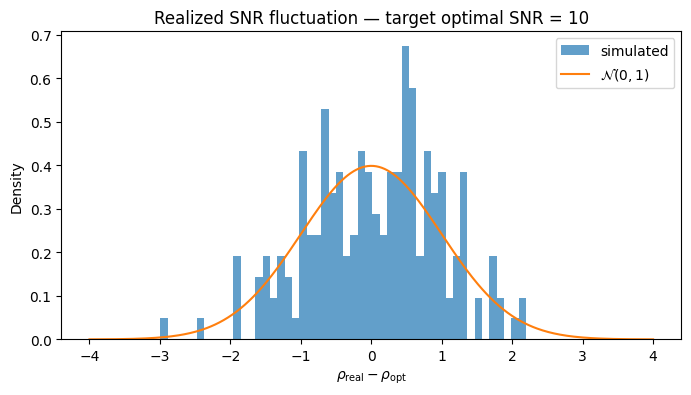

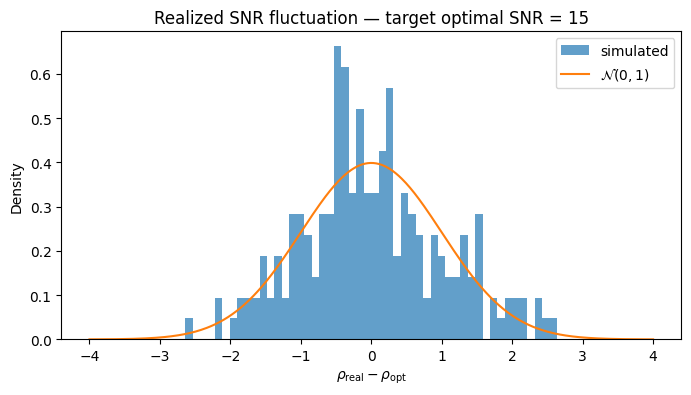

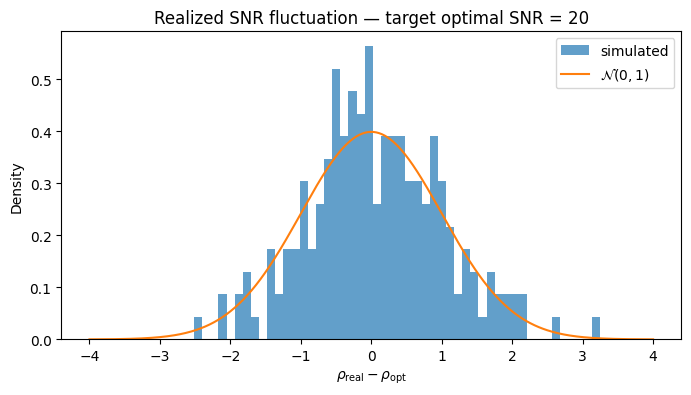

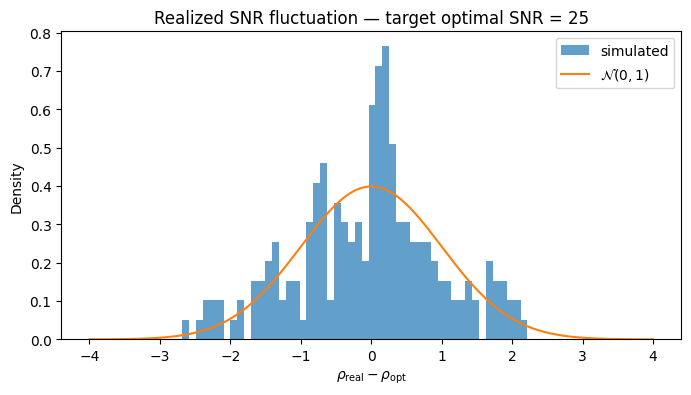

In [20]:
for target in TARGET_SNRS:

    d = df_snr[
        df_snr["target_snr"] == target
    ]

    plt.figure(figsize=(8, 4))

    plt.hist(
        d["delta_rho"],
        bins=50,
        density=True,
        alpha=0.7,
        label="simulated",
    )

    x = np.linspace(-4, 4, 400)

    plt.plot(
        x,
        norm.pdf(x),
        label=r"$\mathcal{N}(0,1)$",
    )

    plt.xlabel(
        r"$\rho_{\rm real}-\rho_{\rm opt}$"
    )
    plt.ylabel("Density")
    plt.title(
        f"Realized SNR fluctuation — "
        f"target optimal SNR = {target:g}"
    )
    plt.legend()
    plt.show()

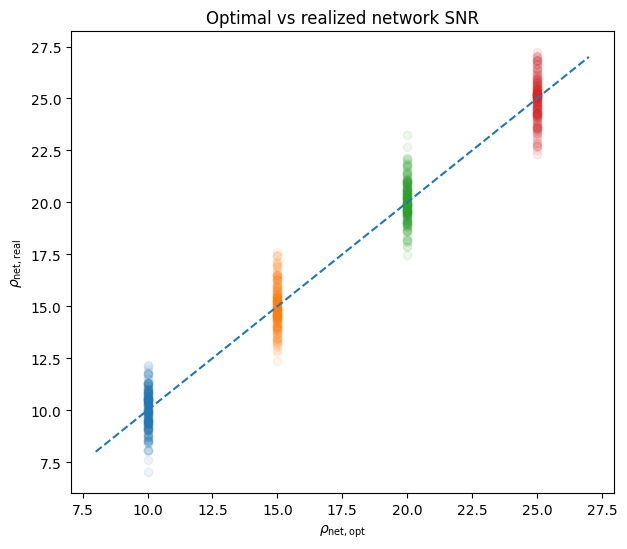

In [21]:
plt.figure(figsize=(7, 6))

for target in TARGET_SNRS:

    d = df_snr[
        df_snr["target_snr"] == target
    ]

    x = np.full(
        len(d),
        target,
    )

    plt.scatter(
        x,
        d["rho_net_real"],
        alpha=0.08,
    )

plt.plot(
    [8, 27],
    [8, 27],
    linestyle="--",
)

plt.xlabel(
    r"$\rho_{\rm net,opt}$"
)
plt.ylabel(
    r"$\rho_{\rm net,real}$"
)
plt.title(
    "Optimal vs realized network SNR"
)
plt.show()

## 8. Relation to the M10 nominal SNR interval

M10 constrains

$$
10\le\rho_{\mathrm{net,opt}}\le25.
$$

This does not imply that every noisy realization satisfies

$$
10\le\rho_{\mathrm{net,real}}\le25.
$$

We quantify the probability that the realized fixed-template SNR falls outside the nominal optimal-SNR interval.

In [22]:
df_snr["real_below_10"] = (
    df_snr["rho_net_real"] < 10.0
)

df_snr["real_above_25"] = (
    df_snr["rho_net_real"] > 25.0
)

df_outside = (
    df_snr
    .groupby("target_snr")
    .agg(
        fraction_below_10=(
            "real_below_10",
            "mean",
        ),
        fraction_above_25=(
            "real_above_25",
            "mean",
        ),
    )
    .reset_index()
)

df_outside

,target_snr,fraction_below_10,fraction_above_25
0,10.0,0.47,0.000
1,15.0,0.00,0.000
2,20.0,0.00,0.000
3,25.0,0.00,0.535


In [23]:
rows = []

for target in TARGET_SNRS:

    d = df_snr[
        df_snr["target_snr"] == target
    ]

    for ifo in DETECTORS:

        delta = d[f"delta_{ifo}"]

        rows.append({
            "target_snr": target,
            "ifo": ifo,
            "rho_opt_detector":
                d[f"rho_opt_{ifo}"].iloc[0],
            "mean_delta":
                delta.mean(),
            "std_delta":
                delta.std(),
            "q05":
                delta.quantile(0.05),
            "q95":
                delta.quantile(0.95),
        })

df_detector_fluctuations = pd.DataFrame(
    rows
)

df_detector_fluctuations

,target_snr,ifo,rho_opt_detector,mean_delta,std_delta,q05,q95
0,10.0,H1,5.790238,0.004705,0.963281,-1.631199,1.578187
1,10.0,L1,7.332314,0.054669,0.939066,-1.580131,1.631957
2,10.0,V1,3.565154,0.022877,0.897179,-1.530213,1.500621
3,15.0,H1,8.685357,0.041973,1.058029,-1.658490,1.614726
4,15.0,L1,10.998471,-0.001712,0.995773,-1.621944,1.489992
5,15.0,V1,5.347731,-0.048363,1.037353,-1.564455,1.744045
6,20.0,H1,11.580475,0.019865,0.996051,-1.553626,1.692196
7,20.0,L1,14.664628,0.018994,0.987088,-1.510056,1.644344
8,20.0,V1,7.130308,0.128505,0.902894,-1.260491,1.600011
9,25.0,H1,14.475594,-0.108161,0.984403,-1.792982,1.441551


# 9. M11.3-A interpretation

M11.3-A distinguishes two quantities that were previously grouped informally under “SNR”.

The production generator controls the deterministic quantity

$$
\rho_{\mathrm{opt}}
=
\sqrt{(h|h)},
$$

which measures the expected detectability of the injected signal for a known PSD.

After adding a particular Gaussian-noise realization, the fixed-template projection becomes

$$
\rho_{\mathrm{real}}
=
\rho_{\mathrm{opt}}
+
\delta\rho.
$$

If the simulation and SNR conventions are mutually consistent, the Gaussian experiment should show approximately

$$
E[\delta\rho]\simeq0,
$$

and

$$
\mathrm{Std}(\delta\rho)\simeq1.
$$

Therefore an M10 sample with a controlled optimal SNR of 10 does not necessarily have a realized SNR greater than 10, and an optimal-SNR-25 sample can realize above 25.

This is expected statistical behavior rather than an SNR-rescaling failure.

## 10. M11.3-A final conclusion

The Gaussian-noise experiment validates the distinction between optimal and realized fixed-template SNR.

The M10 generator controls

$$
\rho_{\rm opt}
=
\sqrt{(h|h)},
$$

while a specific noisy realization produces

$$
\rho_{\rm real}
=
\rho_{\rm opt}
+
\delta\rho.
$$

The measured fluctuations are consistent with

$$
E[\delta\rho]\approx0,
\qquad
\mathrm{Std}(\delta\rho)\approx1
$$

for all tested optimal-SNR values.

Therefore:

- the existing distance-rescaling procedure based on optimal SNR is statistically consistent;
- realized SNR should not replace optimal SNR as the generation target;
- samples at the boundaries of the nominal M10 interval can naturally realize outside $[10,25]$ after noise is added;
- realized SNR is nevertheless useful diagnostic metadata because it describes the particular signal-noise realization seen by the model.

The next experiment studies whether these noise-induced SNR fluctuations are associated with changes in the frozen M10 embedding and parameter predictions.

# 10. M11.3-B — Noise-induced prediction variability at fixed optimal SNR

M11.3-A established that, for stationary Gaussian noise,

$$
\rho_{\rm real}
=
\rho_{\rm opt}
+
\delta\rho,
$$

with approximately

$$
\delta\rho\sim\mathcal N(0,1).
$$

The next question is whether this purely noise-induced fluctuation is visible to the frozen M10 predictor.

We therefore hold fixed:

- the BBH physical parameters;
- detector geometry;
- geocentric time;
- waveform;
- signal placement;
- analytical PSD;
- optimal network SNR.

Only the Gaussian-noise realization is changed.

For realization $j$,

$$
x_j = h + n_j,
$$

with

$$
\rho_{\rm opt}=15
$$

for every sample.

We then measure

$$
\rho_{{\rm real},j},
$$

the processed and M10-normalized CNN input,

$$
Z_j,
$$

the latent representation,

$$
\mathbf z_j,
$$

and the physical predictions

$$
\hat{\mathcal M}_j,\qquad
\hat M_{{\rm tot},j},\qquad
\hat\chi_{{\rm eff},j}.
$$

This experiment estimates the prediction variability caused exclusively by detector-noise realization.

In [24]:
TARGET_B = 15.0

network_B = networks[TARGET_B]

print("Fixed physical event")
print("--------------------")
print("distance [Mpc]:", network_B.params.distance)
print("chirp mass:", network_B.params.chirp_mass)
print("total mass:", network_B.params.total_mass)
print("chi_eff:", network_B.params.chi_eff)
print("network optimal SNR:", network_B.network_snr)
print("detector optimal SNRs:", network_B.detector_snrs)
print("placement start:", network_B.placement.segment_start_time)

Fixed physical event
--------------------
distance [Mpc]: 1672.575433432374
chirp mass: 26.11651689888372
total mass: 60.0
chi_eff: 0.0
network optimal SNR: 15.000000000000002
detector optimal SNRs: {'H1': 8.68535654763675, 'L1': 10.99847066258628, 'V1': 5.347730801438344}
placement start: 1126259459.9145508


In [25]:
assert np.isclose(
    network_B.network_snr,
    TARGET_B,
    rtol=1e-6,
)

assert all(
    len(network_B.signal_segments[ifo])
    == config.length
    for ifo in DETECTORS
)

print("Fixed-signal contract passed.")

Fixed-signal contract passed.


## 11. Exact M10 preprocessing contract

Unlike M11.3-A, which studied SNR directly on raw 4 s segments, M11.3-B propagates the noisy realizations through the frozen M10 predictor.

The preprocessing must therefore reproduce the M10 training pipeline:

- PSD whitening;
- 30 Hz high-pass filter;
- 512 Hz low-pass filter;
- processing context;
- final 4 s crop;
- no internal strain standardization.

The per-sample/per-detector input z-score is applied only after this physical preprocessing.

In [26]:
print(builder.signal_processor.metadata())

{'whitening_method': 'psd', 'apply_lowpass': False, 'apply_highpass': False, 'apply_standardization': False, 'lowpass_frequency': 512.0, 'highpass_frequency': 30.0, 'whitening_low_frequency_cutoff': 30.0, 'whitening_max_filter_duration': 0.5, 'whitening_trunc_method': 'hann', 'fir_order': 256, 'fir_beta': 5.0, 'remove_corrupted': True, 'processing_preset': 'psd_fir256_beta5_crop_to_config_crop', 'corrupted_margin_samples_per_side': 1024, 'corrupted_margin_seconds_per_side': 0.25, 'recommended_safe_margin_start': 0.275, 'recommended_safe_margin_end': 0.275, 'usable_duration_after_processing_margins': 3.45, 'uses_processing_context': True, 'output_mode': 'crop_to_config', 'output_length': 16384, 'output_duration': 4.0, 'processing_input_length': 19712, 'processing_input_duration': 4.8125, 'processing_context_start_samples': 1664, 'processing_context_end_samples': 1664, 'processing_context_start_seconds': 0.40625, 'processing_context_end_seconds': 0.40625}


In [27]:
builder_B = DatasetBuilder.from_config(
    config=config,
    detector_names=DETECTORS,
    signal_processor_kwargs={
        "whitening_method": "psd",
        "apply_highpass": True,
        "apply_lowpass": True,
        "apply_standardization": False,
        "output_mode": "crop_to_config",
        "whitening_low_frequency_cutoff": 30.0,
        "whitening_max_filter_duration": 0.5,
        "whitening_trunc_method": "hann",
        "highpass_frequency": 30.0,
        "lowpass_frequency": 512.0,
        "fir_order": 256,
        "fir_beta": 5.0,
        "remove_corrupted": True,
    },
    rng=np.random.default_rng(123),
)

In [28]:
processor_B = builder_B.signal_processor
noise_model_B = builder_B.noise_model
injector_B = builder_B.signal_injector

processor_B.metadata()

{'whitening_method': 'psd',
 'apply_lowpass': True,
 'apply_highpass': True,
 'apply_standardization': False,
 'lowpass_frequency': 512.0,
 'highpass_frequency': 30.0,
 'whitening_low_frequency_cutoff': 30.0,
 'whitening_max_filter_duration': 0.5,
 'whitening_trunc_method': 'hann',
 'fir_order': 256,
 'fir_beta': 5.0,
 'remove_corrupted': True,
 'processing_preset': 'psd_hp30_lp512_fir256_beta5_crop_to_config_crop',
 'corrupted_margin_samples_per_side': 1536,
 'corrupted_margin_seconds_per_side': 0.375,
 'recommended_safe_margin_start': 0.4,
 'recommended_safe_margin_end': 0.4,
 'usable_duration_after_processing_margins': 3.2,
 'uses_processing_context': True,
 'output_mode': 'crop_to_config',
 'output_length': 16384,
 'output_duration': 4.0,
 'processing_input_length': 19712,
 'processing_input_duration': 4.8125,
 'processing_context_start_samples': 1664,
 'processing_context_end_samples': 1664,
 'processing_context_start_seconds': 0.40625,
 'processing_context_end_seconds': 0.40625}

In [29]:
M10_INPUT_NORM_CONFIG = {
    "enabled": True,
    "mode": "per_sample_per_detector_zscore",
    "eps": 1e-6,
}

In [30]:
def m10_input_zscore(X, config_norm):
    X = np.asarray(X, dtype=np.float64)

    if not config_norm["enabled"]:
        return X.copy(), None, None

    if config_norm["mode"] != "per_sample_per_detector_zscore":
        raise ValueError(
            f"Unsupported mode: {config_norm['mode']}"
        )

    eps = float(config_norm["eps"])

    means = X.mean(axis=1)
    stds = X.std(axis=1)

    if np.any(~np.isfinite(means)):
        raise ValueError("Non-finite means.")

    if np.any(~np.isfinite(stds)):
        raise ValueError("Non-finite stds.")

    if np.any(stds < eps):
        raise ValueError(
            f"Input std below eps={eps}: {stds}"
        )

    Z = (
        X - means[:, None]
    ) / stds[:, None]

    return Z, means, stds

## 12. Cached realized-SNR calculation

The signal template is identical for every realization.

Therefore all template-dependent frequency-domain quantities are computed once.

For each detector,

$$
\delta\rho_I
=
\frac{(n_I|h_I)}
{\rho_{I,\rm opt}}.
$$

At network level,

$$
\delta\rho_{\rm net}
=
\frac{
\sum_I(n_I|h_I)
}{
\rho_{\rm net,opt}
}.
$$

Thus only the FFT of each new noise realization must be evaluated.

In [31]:
psds_4s = {
    ifo: noise_model_B.get_psd(ifo)
    for ifo in DETECTORS
}


def build_snr_cache(
    network,
    psds,
    f_low,
):
    cache = {}

    hh_total = 0.0

    for ifo in DETECTORS:

        h = network.signal_segments[ifo]
        h_f = h.to_frequencyseries()

        psd = psds[ifo]

        freqs = h_f.sample_frequencies.numpy()
        h_arr = h_f.numpy()
        psd_arr = psd.numpy()

        mask = (
            (freqs >= f_low)
            & np.isfinite(psd_arr)
            & (psd_arr > 0)
        )

        df = float(h_f.delta_f)

        hh = (
            4.0
            * df
            * np.real(
                np.sum(
                    np.conjugate(h_arr[mask])
                    * h_arr[mask]
                    / psd_arr[mask]
                )
            )
        )

        cache[ifo] = {
            "h_f": h_arr,
            "psd": psd_arr,
            "mask": mask,
            "delta_f": df,
            "hh": float(hh),
            "rho_opt": float(np.sqrt(hh)),
        }

        hh_total += hh

    return cache, float(np.sqrt(hh_total))

In [32]:
snr_cache_B, rho_net_opt_cached = (
    build_snr_cache(
        network=network_B,
        psds=psds_4s,
        f_low=config.low_frequency_cutoff,
    )
)

print(
    "Cached network optimal SNR:",
    rho_net_opt_cached,
)

print(
    "Production network optimal SNR:",
    network_B.network_snr,
)

assert np.isclose(
    rho_net_opt_cached,
    network_B.network_snr,
    rtol=1e-10,
)

Cached network optimal SNR: 15.000000000000002
Production network optimal SNR: 15.000000000000002


In [33]:
def realized_snr_from_noise_cached(
    noise_segments,
    cache,
    rho_net_opt,
):
    nh_total = 0.0

    detector_delta = {}

    for ifo in DETECTORS:

        n_f = (
            noise_segments[ifo]
            .to_frequencyseries()
            .numpy()
        )

        c = cache[ifo]

        mask = c["mask"]

        nh = (
            4.0
            * c["delta_f"]
            * np.real(
                np.sum(
                    np.conjugate(n_f[mask])
                    * c["h_f"][mask]
                    / c["psd"][mask]
                )
            )
        )

        detector_delta[ifo] = (
            nh / c["rho_opt"]
        )

        nh_total += nh

    delta_net = (
        nh_total / rho_net_opt
    )

    rho_real = (
        rho_net_opt + delta_net
    )

    return (
        float(rho_real),
        float(delta_net),
        detector_delta,
    )

In [34]:
#Helper para el CNN input

OUTPUT_START = (
    network_B.placement.segment_start_time
)

CONTEXT_START = (
    OUTPUT_START
    - config.processing_context_start_seconds
)

PROCESSING_LENGTH = (
    config.processing_length
)

FINAL_START_IDX = (
    config.processing_context_start_samples
)

FINAL_END_IDX = (
    FINAL_START_IDX
    + config.length
)

print("processing length:", PROCESSING_LENGTH)
print("final indices:",
      FINAL_START_IDX,
      FINAL_END_IDX)

processing length: 19712
final indices: 1664 18048


In [35]:
def build_noisy_cnn_input(
    noise_seed,
):
    # 1. Generate only the Gaussian processing-context noise.
    noises_context = noise_model_B.sample_network(
        detector_names=DETECTORS,
        seed=noise_seed,
        length=PROCESSING_LENGTH,
    )

    # 2. Attach the physical absolute time.
    noises_context = {
        ifo: injector_B.set_strain_start_time(
            strain=noise,
            start_time=CONTEXT_START,
            expected_length=PROCESSING_LENGTH,
        )
        for ifo, noise in noises_context.items()
    }

    # 3. Extract the exact final 4 s noise realization
    #    used for the realized-SNR diagnostic.
    noises_final = {}

    for ifo in DETECTORS:

        n_final = noises_context[ifo][
            FINAL_START_IDX:FINAL_END_IDX
        ].copy()

        n_final.start_time = OUTPUT_START

        noises_final[ifo] = n_final

    # 4. M11.1 physically corrected context:
    #    inject the full detector projection.
    injected = injector_B.inject_network(
        noises=noises_context,
        signals=network_B.projection.strains,
    )

    injected_strains = {
        ifo: injected[ifo].strain
        for ifo in DETECTORS
    }

    # 5. Processing-length PSDs.
    psds_context = {
        ifo: noise_model_B.get_psd(
            ifo,
            length=PROCESSING_LENGTH,
        )
        for ifo in DETECTORS
    }

    # 6. Exact M10 processing.
    processed = processor_B.process_network(
        strains=injected_strains,
        psds=psds_context,
    )

    X = np.stack(
        [
            np.asarray(
                processed[ifo],
                dtype=np.float64,
            )
            for ifo in DETECTORS
        ],
        axis=0,
    )

    # 7. Exact M10 input normalization.
    Z, means, stds = m10_input_zscore(
        X,
        M10_INPUT_NORM_CONFIG,
    )

    # 8. Fast realized SNR on the same noise realization.
    rho_real, delta_rho, det_delta = (
        realized_snr_from_noise_cached(
            noise_segments=noises_final,
            cache=snr_cache_B,
            rho_net_opt=rho_net_opt_cached,
        )
    )

    return {
        "Z": Z.astype(np.float32),
        "rho_real": rho_real,
        "delta_rho": delta_rho,
        "detector_delta_rho": det_delta,
        "raw_mean": means,
        "raw_std": stds,
    }

In [36]:
test_B = build_noisy_cnn_input(
    noise_seed=5000
)

print("Z shape:", test_B["Z"].shape)
print("rho real:", test_B["rho_real"])
print("delta rho:", test_B["delta_rho"])
print("detector deltas:",
      test_B["detector_delta_rho"])

print(
    "z-score channel means:",
    test_B["Z"].mean(axis=1),
)

print(
    "z-score channel stds:",
    test_B["Z"].std(axis=1),
)

Z shape: (3, 16384)
rho real: 16.028405750251043
delta rho: 1.0284057502510395
detector deltas: {'H1': np.float64(0.9502064335571289), 'L1': np.float64(0.6122420746779794), 'V1': np.float64(0.08218029366749378)}
z-score channel means: [-8.1490725e-10  7.2759576e-11 -5.2386895e-10]
z-score channel stds: [1. 1. 1.]


In [37]:
assert test_B["Z"].shape == (
    len(DETECTORS),
    config.length,
)

assert np.all(
    np.isfinite(test_B["Z"])
)

assert np.allclose(
    test_B["Z"].mean(axis=1),
    0.0,
    atol=1e-5,
)

assert np.allclose(
    test_B["Z"].std(axis=1),
    1.0,
    atol=1e-5,
)

print("Single-realization sanity checks passed.")

Single-realization sanity checks passed.


## 13. Fixed-signal noise ensemble

We generate 50 independent Gaussian-noise realizations.

This is intentionally smaller than M11.3-A because each realization must now pass through the complete M10 preprocessing chain.

Waveform generation, detector projection, placement, signal SNR and model construction are not repeated.

The only stochastic variable is the Gaussian noise realization.

In [39]:
N_B = 100
B_SEED0 = 10_000

B_results = []

for j in range(N_B):

    result = build_noisy_cnn_input(
        noise_seed=B_SEED0 + j
    )

    B_results.append(result)

    if (j + 1) % 10 == 0:
        print(
            f"{j + 1}/{N_B} realizations built"
        )

10/100 realizations built
20/100 realizations built
30/100 realizations built
40/100 realizations built
50/100 realizations built
60/100 realizations built
70/100 realizations built
80/100 realizations built
90/100 realizations built
100/100 realizations built


In [40]:
Z_batch = np.stack(
    [r["Z"] for r in B_results],
    axis=0,
)

rho_real_B = np.asarray(
    [r["rho_real"] for r in B_results]
)

delta_rho_B = np.asarray(
    [r["delta_rho"] for r in B_results]
)

raw_std_B = np.stack(
    [r["raw_std"] for r in B_results],
    axis=0,
)

print("Z batch:", Z_batch.shape)
print(
    "rho realized mean/std:",
    rho_real_B.mean(),
    rho_real_B.std(ddof=1),
)

print(
    "delta rho mean/std:",
    delta_rho_B.mean(),
    delta_rho_B.std(ddof=1),
)

Z batch: (100, 3, 16384)
rho realized mean/std: 14.965854574799508 0.998954583407269
delta rho mean/std: -0.03414542520049136 0.998954583407269


## Load the frozen M10 Model

In [41]:
from pathlib import Path
import importlib
import torch

DATA_ROOT = Path("/data/vserrano/cbc_pe_data")
DATASET_ID = "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"

PRED_PATH = (
    DATA_ROOT
    / "results"
    / DATASET_ID
    / "m10_inputzscore_500k_cal_test_predictions_embeddings.npz"
)

CHECKPOINT_PATH = (
    DATA_ROOT
    / "models"
    / "checkpoints"
    / DATASET_ID
    / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_"
        "SimpleCNN_ResidualDilated_"
        "M10_inputzscore_resdilated_emb64_d124_train400k_"
        "MSELoss_seed123_checkpoint.pt"
    )
)

assert PRED_PATH.exists(), PRED_PATH
assert CHECKPOINT_PATH.exists(), CHECKPOINT_PATH

print("Prediction artifact:", PRED_PATH)
print("Checkpoint:", CHECKPOINT_PATH)

Prediction artifact: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/m10_inputzscore_500k_cal_test_predictions_embeddings.npz
Checkpoint: /data/vserrano/cbc_pe_data/models/checkpoints/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_M10_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_checkpoint.pt


In [44]:
pred_data = np.load(
    PRED_PATH,
    allow_pickle=True,
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
)

# Frozen M10 metadata
label_mean = pred_data["y_mean"].astype(np.float32)
label_std = pred_data["y_std"].astype(np.float32)
label_names = [
    str(x)
    for x in pred_data["label_names"].tolist()
]

model_config_pred = pred_data["model_config"].item()
input_norm_config = pred_data["input_normalization"].item()

model_config_ckpt = checkpoint["model_config"]

print("Device:", device)
print("Labels:", label_names)
print("Input normalization:", input_norm_config)
print("Checkpoint epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["best_val_loss"])

Device: cpu
Labels: ['chirp_mass', 'total_mass', 'chi_eff']
Input normalization: {'enabled': True, 'mode': 'per_sample_per_detector_zscore', 'eps': 1e-06}
Checkpoint epoch: 69
Best validation loss: 0.11357601894140243


In [45]:
assert model_config_ckpt == model_config_pred

assert np.allclose(
    checkpoint["y_mean"],
    label_mean,
)

assert np.allclose(
    checkpoint["y_std"],
    label_std,
)

assert (
    model_config_ckpt["input_normalization"]
    == input_norm_config
)

assert input_norm_config == {
    "enabled": True,
    "mode": "per_sample_per_detector_zscore",
    "eps": 1e-6,
}

print("M10 model contract verified.")

M10 model contract verified.


In [46]:
model_config = model_config_ckpt

network_module = importlib.import_module(
    "src.models.network"
)

class_name = model_config["class_name"]
model_kwargs = dict(
    model_config["model_kwargs"]
)

model_class = getattr(
    network_module,
    class_name,
)

model = model_class(
    **model_kwargs,
).to(device)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print(
    f"Loaded frozen M10 model: {class_name}"
)
print("Model kwargs:")
model_kwargs

Loaded frozen M10 model: SimpleCNN_ResidualDilated
Model kwargs:


{'n_detectors': 3,
 'n_outputs': 3,
 'embedding_dim': 64,
 'residual_channels': 64,
 'dilations': [1, 2, 4],
 'residual_kernel_size': 7,
 'dropout_conv': 0.05,
 'dropout_dense': 0.1,
 'num_groups': 8}

In [47]:
assert (
    input_norm_config
    == M10_INPUT_NORM_CONFIG
)

print("Frozen M10 normalization verified.")

Frozen M10 normalization verified.


In [48]:
X_tensor = torch.as_tensor(
    Z_batch,
    dtype=torch.float32,
    device=device,
)

model.eval()

with torch.no_grad():

    pred_std_B, emb_B = model(
        X_tensor,
        return_embedding=True,
    )

pred_std_B = (
    pred_std_B
    .cpu()
    .numpy()
)

emb_B = (
    emb_B
    .cpu()
    .numpy()
)

print(
    "predictions:",
    pred_std_B.shape,
)

print(
    "embeddings:",
    emb_B.shape,
)

predictions: (100, 3)
embeddings: (100, 64)


In [49]:
pred_phys_B = (
    pred_std_B
    * label_std[None, :]
    + label_mean[None, :]
)

LABELS = [
    "chirp_mass",
    "total_mass",
    "chi_eff",
]

true_B = np.asarray([
    network_B.params.chirp_mass,
    network_B.params.total_mass,
    network_B.params.chi_eff,
])

residuals_B = (
    pred_phys_B
    - true_B[None, :]
)

abs_errors_B = np.abs(
    residuals_B
)

In [51]:
# Main DataFrame

df_B = pd.DataFrame({
    "noise_index": np.arange(N_B),
    "noise_seed": B_SEED0 + np.arange(N_B),
    "rho_opt": rho_net_opt_cached,
    "rho_real": rho_real_B,
    "delta_rho": delta_rho_B,
})

for j, label in enumerate(LABELS):

    df_B[f"pred_{label}"] = (
        pred_phys_B[:, j]
    )

    df_B[f"residual_{label}"] = (
        residuals_B[:, j]
    )

    df_B[f"abs_error_{label}"] = (
        abs_errors_B[:, j]
    )

df_B.head()

,noise_index,noise_seed,rho_opt,rho_real,delta_rho,pred_chirp_mass,residual_chirp_mass,abs_error_chirp_mass,pred_total_mass,residual_total_mass,abs_error_total_mass,pred_chi_eff,residual_chi_eff,abs_error_chi_eff
0,0,10000,15.0,14.793125,-0.206875,23.057995,-3.058522,3.058522,74.862381,14.862381,14.862381,0.075012,0.075012,0.075012
1,1,10001,15.0,14.386457,-0.613543,24.321678,-1.794839,1.794839,58.025219,-1.974781,1.974781,-0.231532,-0.231532,0.231532
2,2,10002,15.0,14.939746,-0.060254,27.661831,1.545314,1.545314,66.960037,6.960037,6.960037,0.077822,0.077822,0.077822
3,3,10003,15.0,16.218058,1.218058,28.690077,2.573560,2.573560,68.741501,8.741501,8.741501,0.136722,0.136722,0.136722
4,4,10004,15.0,16.585090,1.585090,26.389975,0.273458,0.273458,61.262051,1.262051,1.262051,-0.004936,-0.004936,0.004936


## 14. Prediction variability induced only by Gaussian noise

Because the physical event is identical in every realization, any variation in the CNN output is caused exclusively by the noise realization.

For target $k$, we estimate

$$
\sigma_{{\rm noise},k}
=
\mathrm{Std}_n
\left[
\hat y_k(h+n)
\right].
$$

This is not a calibrated predictive uncertainty.

It is a controlled estimate of the sensitivity of the frozen point predictor to Gaussian-noise realization for one fixed physical event.

In [52]:
rows = []

for j, label in enumerate(LABELS):

    pred = pred_phys_B[:, j]
    residual = residuals_B[:, j]

    rows.append({
        "label": label,
        "truth": true_B[j],
        "mean_prediction":
            np.mean(pred),
        "prediction_std_noise":
            np.std(pred, ddof=1),
        "prediction_min":
            np.min(pred),
        "prediction_max":
            np.max(pred),
        "mean_residual":
            np.mean(residual),
        "rmse_over_noise":
            np.sqrt(
                np.mean(residual**2)
            ),
        "mae_over_noise":
            np.mean(
                np.abs(residual)
            ),
    })

df_noise_prediction_summary = pd.DataFrame(
    rows
)

df_noise_prediction_summary

,label,truth,mean_prediction,prediction_std_noise,prediction_min,prediction_max,mean_residual,rmse_over_noise,mae_over_noise
0,chirp_mass,26.116517,26.100132,1.792508,20.153618,30.093233,-0.016387,1.783598,1.448303
1,total_mass,60.000000,64.141632,4.176248,53.989708,74.862381,4.141624,5.866830,4.671393
2,chi_eff,0.000000,-0.010478,0.139257,-0.398186,0.301289,-0.010478,0.138954,0.110859


## 15. Does realized SNR drive the prediction fluctuation?

At fixed optimal SNR, variation in realized SNR is produced only by the projection of the Gaussian noise onto the true signal.

For each regression target we therefore evaluate whether

$$
\Delta\rho
$$

is associated with either the point prediction or its residual.

A strong correlation would indicate that favorable or unfavorable matched-filter noise fluctuations systematically move the CNN estimate.

A weak correlation would indicate that the CNN response to noise cannot be summarized by realized SNR alone.

In [54]:
from scipy.stats import (
    pearsonr,
    spearmanr,
)

rows = []

for label in LABELS:

    pred = df_B[f"pred_{label}"].to_numpy()
    residual = df_B[
        f"residual_{label}"
    ].to_numpy()

    p_pred = pearsonr(
        delta_rho_B,
        pred,
    )

    s_pred = spearmanr(
        delta_rho_B,
        pred,
    )

    p_res = pearsonr(
        delta_rho_B,
        residual,
    )

    s_res = spearmanr(
        delta_rho_B,
        residual,
    )

    rows.append({
        "label": label,

        "pearson_delta_rho_pred":
            p_pred.statistic,
        "pearson_pred_p":
            p_pred.pvalue,

        "spearman_delta_rho_pred":
            s_pred.statistic,
        "spearman_pred_p":
            s_pred.pvalue,

        "pearson_delta_rho_residual":
            p_res.statistic,
        "pearson_residual_p":
            p_res.pvalue,

        "spearman_delta_rho_residual":
            s_res.statistic,
        "spearman_residual_p":
            s_res.pvalue,
    })

df_snr_prediction_correlation = pd.DataFrame(
    rows
)

df_snr_prediction_correlation

,label,pearson_delta_rho_pred,pearson_pred_p,spearman_delta_rho_pred,spearman_pred_p,pearson_delta_rho_residual,pearson_residual_p,spearman_delta_rho_residual,spearman_residual_p
0,chirp_mass,0.105747,0.295047,0.102622,0.309627,0.105747,0.295047,0.102622,0.309627
1,total_mass,0.152523,0.129789,0.189595,0.058853,0.152523,0.129789,0.189595,0.058853
2,chi_eff,0.143692,0.153790,0.168773,0.093235,0.143692,0.153790,0.168773,0.093235


In [55]:
from scipy.stats import linregress

rows = []

for label in LABELS:

    y = df_B[
        f"pred_{label}"
    ].to_numpy()

    fit = linregress(
        delta_rho_B,
        y,
    )

    rows.append({
        "label": label,
        "slope_per_snr":
            fit.slope,
        "intercept":
            fit.intercept,
        "r_value":
            fit.rvalue,
        "r_squared":
            fit.rvalue**2,
        "p_value":
            fit.pvalue,
        "slope_stderr":
            fit.stderr,
    })

df_snr_slopes = pd.DataFrame(
    rows
)

df_snr_slopes

,label,slope_per_snr,intercept,r_value,r_squared,p_value,slope_stderr
0,chirp_mass,0.189750,26.106611,0.105747,0.011182,0.295047,0.180244
1,total_mass,0.637641,64.163405,0.152523,0.023263,0.129789,0.417365
2,chi_eff,0.020031,-0.009794,0.143692,0.020647,0.153790,0.013936


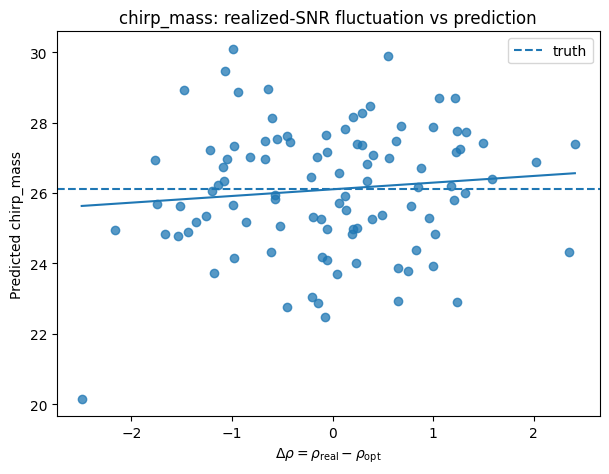

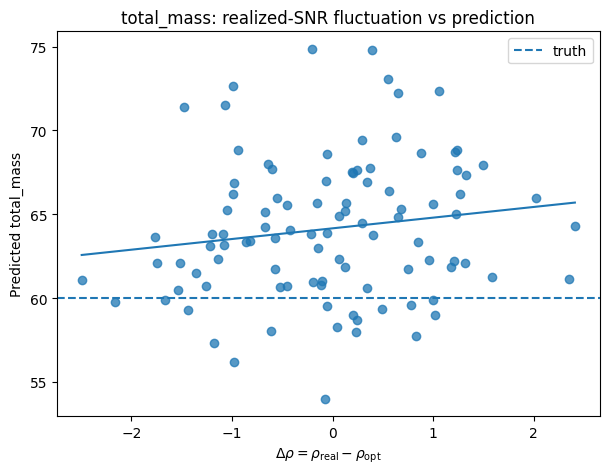

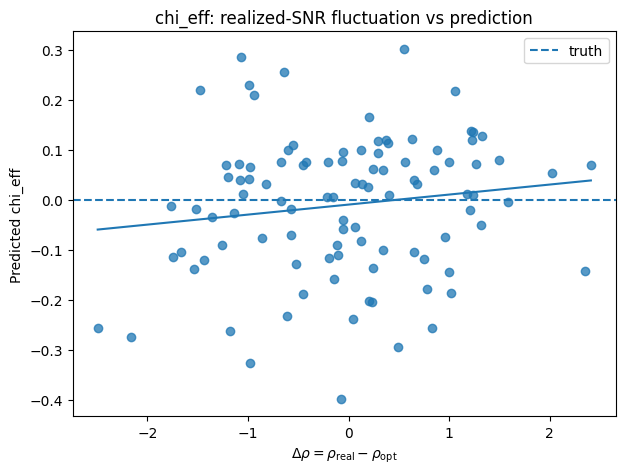

In [56]:
for label in LABELS:

    plt.figure(figsize=(7, 5))

    plt.scatter(
        df_B["delta_rho"],
        df_B[f"pred_{label}"],
        alpha=0.75,
    )

    fit = linregress(
        df_B["delta_rho"],
        df_B[f"pred_{label}"],
    )

    x = np.linspace(
        df_B["delta_rho"].min(),
        df_B["delta_rho"].max(),
        100,
    )

    plt.plot(
        x,
        fit.intercept
        + fit.slope * x,
    )

    plt.axhline(
        true_B[LABELS.index(label)],
        linestyle="--",
        label="truth",
    )

    plt.xlabel(
        r"$\Delta\rho = "
        r"\rho_{\rm real}-"
        r"\rho_{\rm opt}$"
    )

    plt.ylabel(
        f"Predicted {label}"
    )

    plt.title(
        f"{label}: realized-SNR fluctuation "
        "vs prediction"
    )

    plt.legend()
    plt.show()

## 16. Noise-induced latent-space variability

The physical event is fixed, so the spread of the 64-dimensional embedding measures how much the learned representation changes under different Gaussian-noise realizations.

We define the ensemble centroid

$$
\bar{\mathbf z}
=
\frac{1}{N}
\sum_j \mathbf z_j
$$

and the realization-specific displacement

$$
d_j
=
\|\mathbf z_j-\bar{\mathbf z}\|_2.
$$

In [57]:
emb_centroid = emb_B.mean(
    axis=0
)

embedding_distance = np.linalg.norm(
    emb_B
    - emb_centroid[None, :],
    axis=1,
)

df_B["embedding_distance_to_centroid"] = (
    embedding_distance
)

print(
    pd.Series(
        embedding_distance
    ).describe()
)

count    100.000000
mean       0.365712
std        0.204904
min        0.081985
25%        0.229835
50%        0.297237
75%        0.463534
max        1.037621
dtype: float64


In [58]:
pearson_embedding = pearsonr(
    np.abs(delta_rho_B),
    embedding_distance,
)

spearman_embedding = spearmanr(
    np.abs(delta_rho_B),
    embedding_distance,
)

print(
    "Pearson |delta rho| vs embedding distance:",
    pearson_embedding,
)

print(
    "Spearman |delta rho| vs embedding distance:",
    spearman_embedding,
)

Pearson |delta rho| vs embedding distance: PearsonRResult(statistic=np.float64(-0.0431054006183785), pvalue=np.float64(0.6702298235520971))
Spearman |delta rho| vs embedding distance: SignificanceResult(statistic=np.float64(-0.10937893789378936), pvalue=np.float64(0.2786789284424923))


Here we also check the variation of noise with the mean total error:

$$
R_k = \frac{\sigma{{\rm noise}, k}}{|{\overline{\hat{y}_k}}-y_k|}
$$

In [59]:
rows = []

for j, label in enumerate(LABELS):

    pred = pred_phys_B[:, j]

    noise_std = np.std(
        pred,
        ddof=1,
    )

    bias = (
        np.mean(pred)
        - true_B[j]
    )

    rows.append({
        "label": label,
        "noise_std": noise_std,
        "absolute_bias": abs(bias),
        "noise_std_over_abs_bias":
            (
                noise_std / abs(bias)
                if abs(bias) > 1e-12
                else np.nan
            ),
    })

df_noise_vs_bias = pd.DataFrame(
    rows
)

df_noise_vs_bias

,label,noise_std,absolute_bias,noise_std_over_abs_bias
0,chirp_mass,1.792508,0.016385,109.399898
1,total_mass,4.176248,4.141632,1.008358
2,chi_eff,0.139257,0.010478,13.289981


# 17. M11.3-B interpretation

M11.3-B keeps the physical GW event and its optimal SNR fixed while changing only the Gaussian-noise realization.

The experiment therefore separates two sources of prediction error:

$$
\text{systematic event-level bias}
$$

and

$$
\text{noise-induced prediction variability}.
$$

The realized matched-filter SNR provides one scalar description of how favorable each noise realization is with respect to the injected signal,

$$
\Delta\rho
=
\rho_{\rm real}
-
\rho_{\rm opt}.
$$

However, the CNN receives the full three-detector time series rather than this scalar quantity. Therefore a weak correlation between $\Delta\rho$ and prediction error would not imply noise insensitivity; it would indicate that the effect of noise on the learned representation is higher-dimensional than realized SNR alone.

The principal quantities to interpret are:

$$
\mathrm{Std}_n(\hat y),
$$

the noise-induced prediction spread;

$$
\mathrm{Bias}_n(\hat y),
$$

the average event-level prediction bias;

and the displacement of the latent representation across noise realizations.

These diagnostics determine whether realized SNR should be retained mainly as metadata or whether it is a useful predictor of model difficulty.

# 18. M11.3-B final conclusion

M11.3-B isolates the effect of the Gaussian-noise realization on the frozen M10 predictor.

A single physical BBH event is held fixed, including its waveform, detector geometry, placement and optimal network SNR,

$$
\rho_{\rm net,opt}=15.
$$

Only the Gaussian-noise realization is varied:

$$
x_j=h+n_j.
$$

This produces the expected realized-SNR fluctuations,

$$
\rho_{{\rm real},j}
=
\rho_{\rm opt}+\Delta\rho_j,
$$

with an ensemble mean close to the fixed optimal SNR and an approximately unit-width distribution of $\Delta\rho$.

## Prediction variability

Although the physical event is identical in every realization, the frozen M10 predictor exhibits a non-negligible noise-induced spread.

For this controlled event, the measured prediction standard deviations are approximately

$$
\sigma_n(\hat{\mathcal M})
\simeq 1.8\,M_\odot,
$$

$$
\sigma_n(\hat M_{\rm tot})
\simeq 4.2\,M_\odot,
$$

and

$$
\sigma_n(\hat\chi_{\rm eff})
\simeq 0.14.
$$

These quantities do **not** represent calibrated predictive uncertainties. They measure how much the deterministic point estimator changes when the same physical signal is observed in different statistically equivalent Gaussian-noise realizations.

## Realized SNR is not sufficient to describe noise difficulty

The correlations between

$$
\Delta\rho
=
\rho_{\rm real}-\rho_{\rm opt}
$$

and the CNN predictions are weak.

The corresponding linear models explain only a small fraction of the prediction variance.

Therefore, although the noise realization substantially affects the CNN output,

$$
\text{noise effect}
\not\approx
f(\Delta\rho)
$$

for any simple one-dimensional function of realized SNR.

This is physically reasonable: $\Delta\rho$ describes only the projection of the noise onto the exact injected template, whereas the CNN receives the full three-detector time series and can respond to temporal and spectral noise structure orthogonal to that projection.

## Latent-space result

The 64-dimensional embedding also changes appreciably across noise realizations, demonstrating that Gaussian noise modifies the internal representation of an otherwise identical event.

However, the embedding displacement is essentially uncorrelated with

$$
|\Delta\rho|.
$$

This independently supports the conclusion that realized SNR is an incomplete scalar description of CNN noise difficulty.

## Methodological conclusion

M11.3-B establishes three distinct concepts:

1. **Optimal SNR** describes the deterministic signal strength used during synthetic generation.

2. **Realized SNR** describes the favorable or unfavorable projection of a particular noise realization onto the true signal.

3. **CNN noise sensitivity** is higher-dimensional and cannot generally be reduced to realized SNR alone.

Optimal SNR should therefore remain the controlled generation variable.

Realized SNR is nevertheless valuable diagnostic metadata, but it should not be interpreted as a complete measure of example difficulty.

The remaining M11.3 question is whether the magnitude of noise-induced prediction variability increases systematically as the optimal signal strength decreases.

In [60]:
C_TARGET_SNRS = [10.0, 15.0, 20.0, 25.0]
N_C = 20
C_SEED0 = 20_000

# 19. M11.3-C — Noise sensitivity as a function of optimal SNR

M11.3-B quantified noise-induced prediction variability for one event at

$$
\rho_{\rm net,opt}=15.
$$

M11.3-C asks whether this variability depends systematically on the deterministic signal strength.

The same physical BBH source is evaluated at

$$
\rho_{\rm net,opt}
\in
\{10,15,20,25\}.
$$

Only luminosity distance is changed to obtain the four optimal-SNR values. Therefore the intrinsic source parameters and regression targets remain identical.

For each SNR level, the same set of Gaussian-noise realizations is used.

This paired design controls for random differences between noise ensembles and isolates the effect of changing signal strength.

In [61]:
for target in C_TARGET_SNRS:

    network = networks[target]

    print(
        f"target={target:4.1f} | "
        f"rho_opt={network.network_snr:.6f} | "
        f"distance={network.params.distance:.3f} Mpc"
    )

    assert np.isclose(
        network.network_snr,
        target,
        rtol=1e-6,
    )

target=10.0 | rho_opt=10.000000 | distance=2508.863 Mpc
target=15.0 | rho_opt=15.000000 | distance=1672.575 Mpc
target=20.0 | rho_opt=20.000000 | distance=1254.432 Mpc
target=25.0 | rho_opt=25.000000 | distance=1003.545 Mpc


In [62]:
reference = networks[C_TARGET_SNRS[0]].params

for target in C_TARGET_SNRS[1:]:

    p = networks[target].params

    assert np.isclose(
        p.chirp_mass,
        reference.chirp_mass,
    )

    assert np.isclose(
        p.total_mass,
        reference.total_mass,
    )

    assert np.isclose(
        p.chi_eff,
        reference.chi_eff,
    )

print("Physical regression targets are identical.")

Physical regression targets are identical.


In [63]:
snr_caches_C = {}
rho_opt_cached_C = {}

for target in C_TARGET_SNRS:

    cache, rho_opt = build_snr_cache(
        network=networks[target],
        psds=psds_4s,
        f_low=config.low_frequency_cutoff,
    )

    snr_caches_C[target] = cache
    rho_opt_cached_C[target] = rho_opt

    assert np.isclose(
        rho_opt,
        target,
        rtol=1e-6,
    )

In [64]:
#Generar el ruido solo una vez

C_SEEDS = [
    C_SEED0 + j
    for j in range(N_C)
]

noise_context_cache = {}

for seed in C_SEEDS:

    noises = noise_model_B.sample_network(
        detector_names=DETECTORS,
        seed=seed,
        length=PROCESSING_LENGTH,
    )

    noises = {
        ifo: injector_B.set_strain_start_time(
            strain=noise,
            start_time=CONTEXT_START,
            expected_length=PROCESSING_LENGTH,
        )
        for ifo, noise in noises.items()
    }

    noise_context_cache[seed] = noises

print(
    f"Cached {len(noise_context_cache)} "
    "processing-context noise realizations."
)

Cached 20 processing-context noise realizations.


In [65]:
def build_cnn_input_from_cached_noise(
    network,
    noises_context,
):
    injected = injector_B.inject_network(
        noises=noises_context,
        signals=network.projection.strains,
    )

    injected_strains = {
        ifo: injected[ifo].strain
        for ifo in DETECTORS
    }

    psds_context = {
        ifo: noise_model_B.get_psd(
            ifo,
            length=PROCESSING_LENGTH,
        )
        for ifo in DETECTORS
    }

    processed = processor_B.process_network(
        strains=injected_strains,
        psds=psds_context,
    )

    X = np.stack(
        [
            np.asarray(
                processed[ifo],
                dtype=np.float64,
            )
            for ifo in DETECTORS
        ],
        axis=0,
    )

    Z, means, stds = m10_input_zscore(
        X,
        M10_INPUT_NORM_CONFIG,
    )

    return (
        Z.astype(np.float32),
        means,
        stds,
    )

In [66]:
#Build the 80 inputs

C_records = []
Z_C = []

for target in C_TARGET_SNRS:

    network = networks[target]

    for noise_index, seed in enumerate(C_SEEDS):

        noises_context = noise_context_cache[seed]

        Z, means, stds = (
            build_cnn_input_from_cached_noise(
                network=network,
                noises_context=noises_context,
            )
        )

        Z_C.append(Z)

        C_records.append({
            "target_snr": target,
            "noise_index": noise_index,
            "noise_seed": seed,
            "raw_mean": means,
            "raw_std": stds,
        })

Z_C = np.stack(
    Z_C,
    axis=0,
)

print("CNN batch shape:", Z_C.shape)

CNN batch shape: (80, 3, 16384)


In [67]:
# Inference in one batch

Z_C_tensor = torch.as_tensor(
    Z_C,
    dtype=torch.float32,
    device=device,
)

model.eval()

with torch.no_grad():

    pred_std_C, emb_C = model(
        Z_C_tensor,
        return_embedding=True,
    )

pred_std_C = (
    pred_std_C
    .cpu()
    .numpy()
)

emb_C = (
    emb_C
    .cpu()
    .numpy()
)

pred_phys_C = (
    pred_std_C
    * label_std[None, :]
    + label_mean[None, :]
)

print(pred_phys_C.shape)
print(emb_C.shape)

(80, 3)
(80, 64)


In [68]:
df_C = pd.DataFrame({
    "target_snr": [
        r["target_snr"]
        for r in C_records
    ],
    "noise_index": [
        r["noise_index"]
        for r in C_records
    ],
    "noise_seed": [
        r["noise_seed"]
        for r in C_records
    ],
})

for j, label in enumerate(LABELS):

    df_C[f"pred_{label}"] = (
        pred_phys_C[:, j]
    )

    df_C[f"residual_{label}"] = (
        pred_phys_C[:, j]
        - true_B[j]
    )

    df_C[f"abs_error_{label}"] = np.abs(
        df_C[f"residual_{label}"]
    )

## 20. Noise-induced prediction spread versus optimal SNR

For each target parameter $y_k$ and optimal-SNR level, we estimate

$$
\sigma_{n,k}(\rho_{\rm opt})
=
\mathrm{Std}_n
\left[
\hat y_k
\mid
\rho_{\rm opt}
\right].
$$

This is the principal M11.3-C diagnostic.

If lower-SNR signals are intrinsically harder for the frozen predictor, we expect

$$
\sigma_{n,k}(10)
>
\sigma_{n,k}(15)
>
\sigma_{n,k}(20)
>
\sigma_{n,k}(25)
$$

at least approximately.

Strict monotonicity is not required with only 20 realizations per SNR level.

In [69]:
rows = []

for target in C_TARGET_SNRS:

    d = df_C[
        df_C["target_snr"] == target
    ]

    for j, label in enumerate(LABELS):

        pred = d[
            f"pred_{label}"
        ].to_numpy()

        residual = d[
            f"residual_{label}"
        ].to_numpy()

        rows.append({
            "target_snr": target,
            "label": label,
            "n": len(d),
            "mean_prediction":
                np.mean(pred),
            "prediction_std_noise":
                np.std(
                    pred,
                    ddof=1,
                ),
            "bias":
                np.mean(residual),
            "rmse_over_noise":
                np.sqrt(
                    np.mean(
                        residual**2
                    )
                ),
            "mae_over_noise":
                np.mean(
                    np.abs(residual)
                ),
        })

df_C_summary = pd.DataFrame(rows)

df_C_summary

,target_snr,label,n,mean_prediction,prediction_std_noise,bias,rmse_over_noise,mae_over_noise
0,10.0,chirp_mass,20,28.025112,3.860185,1.908597,4.218853,3.143262
1,10.0,total_mass,20,70.462570,9.496502,10.462576,13.969248,11.026443
2,10.0,chi_eff,20,0.114986,0.242606,0.114986,0.262939,0.201005
3,15.0,chirp_mass,20,26.415527,1.833931,0.299010,1.812331,1.356298
4,15.0,total_mass,20,63.884594,4.552036,3.884598,5.897040,4.386121
5,15.0,chi_eff,20,-0.004294,0.139453,-0.004294,0.135990,0.102166
6,20.0,chirp_mass,20,26.286386,1.091754,0.169870,1.077584,0.828384
7,20.0,total_mass,20,62.766888,2.993307,2.766889,4.020892,3.020217
8,20.0,chi_eff,20,-0.031204,0.099994,-0.031204,0.102336,0.084703
9,25.0,chirp_mass,20,26.130039,0.815381,0.013522,0.794850,0.684996


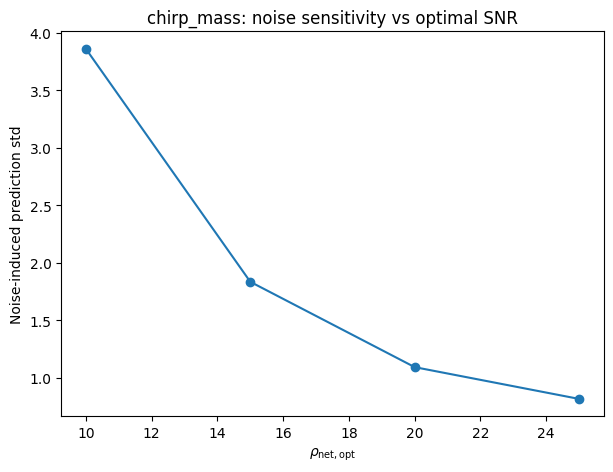

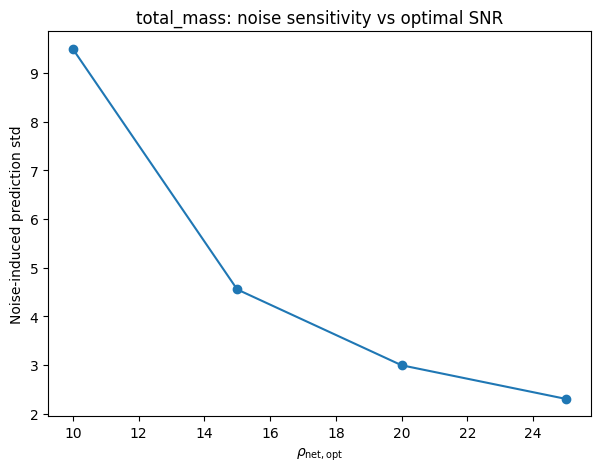

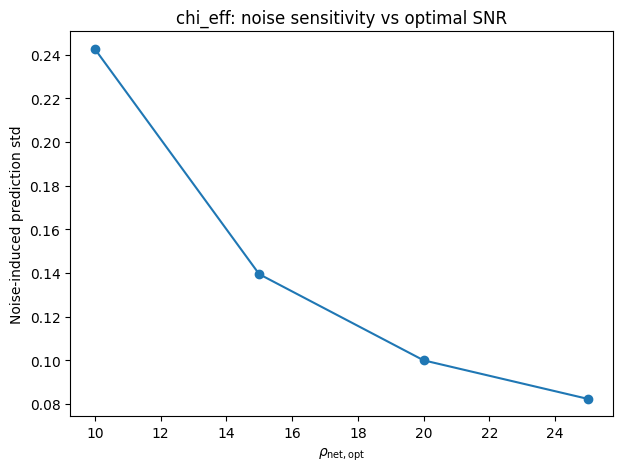

In [70]:
for label in LABELS:

    d = df_C_summary[
        df_C_summary["label"] == label
    ]

    plt.figure(figsize=(7, 5))

    plt.plot(
        d["target_snr"],
        d["prediction_std_noise"],
        marker="o",
    )

    plt.xlabel(
        r"$\rho_{\rm net,opt}$"
    )

    plt.ylabel(
        "Noise-induced prediction std"
    )

    plt.title(
        f"{label}: noise sensitivity vs optimal SNR"
    )

    plt.show()

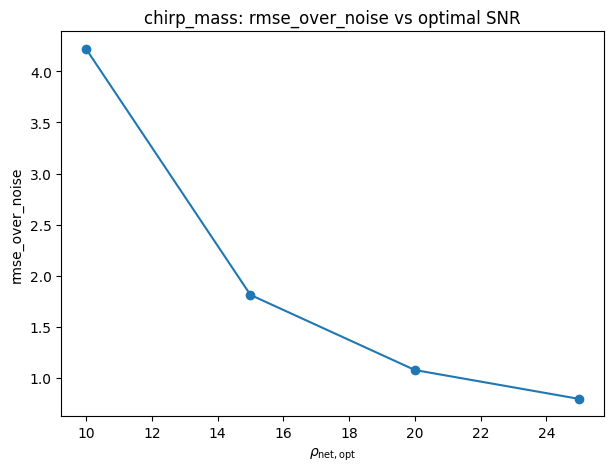

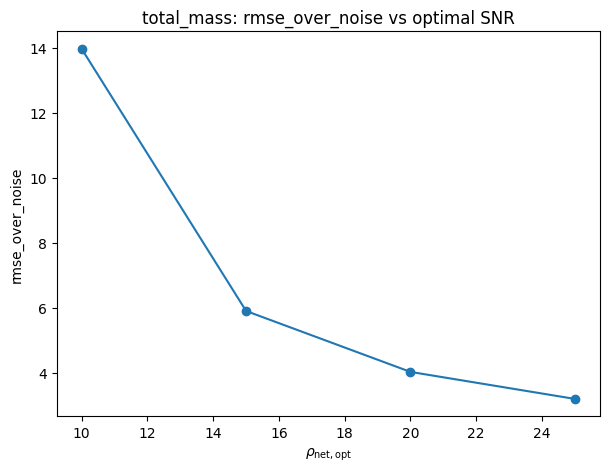

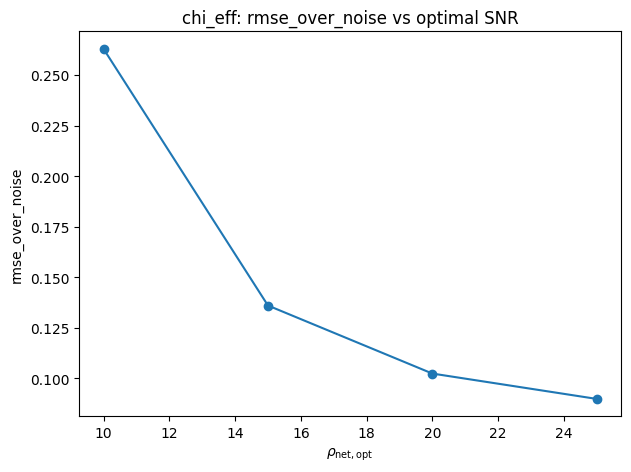

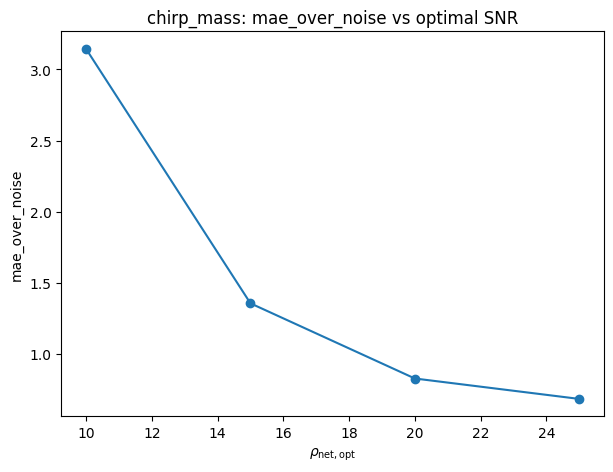

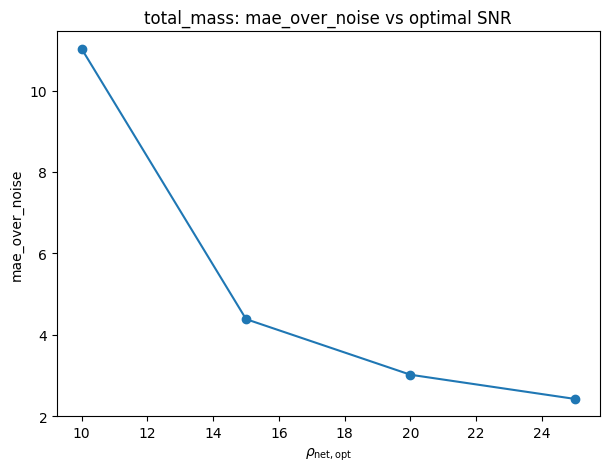

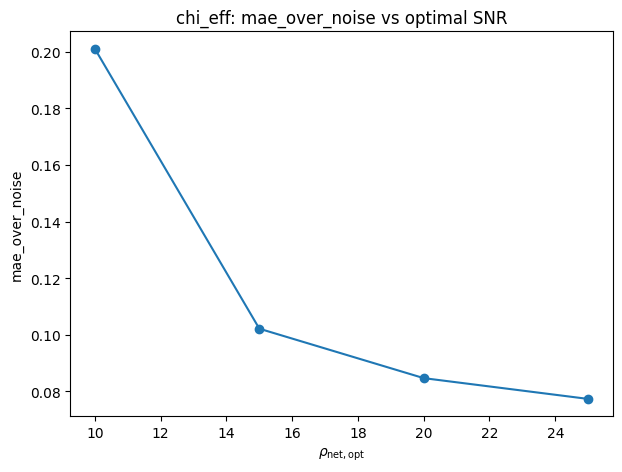

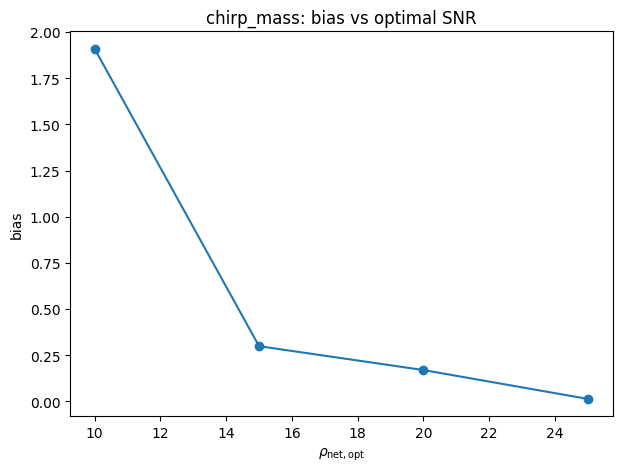

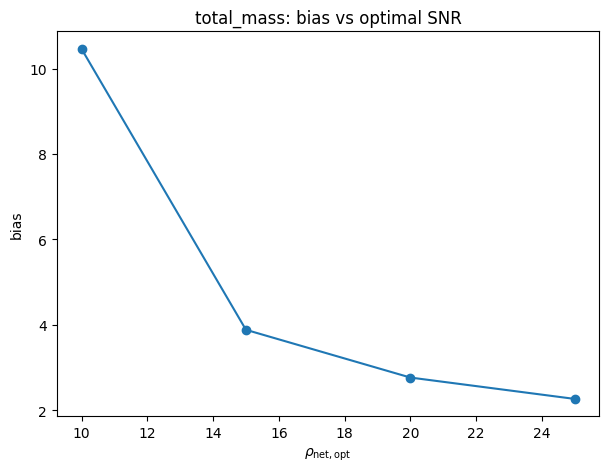

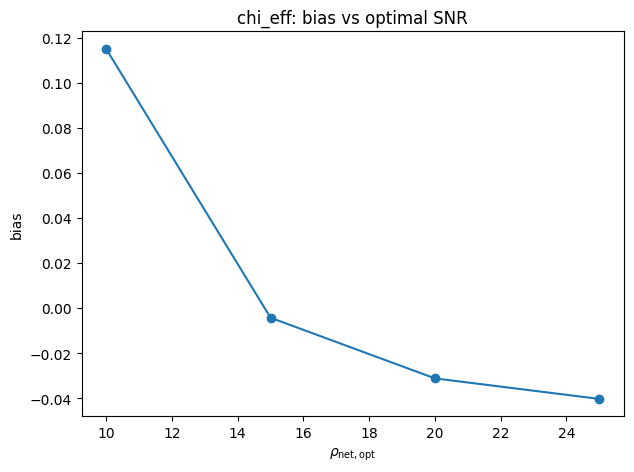

In [71]:
for metric in [
    "rmse_over_noise",
    "mae_over_noise",
    "bias",
]:

    for label in LABELS:

        d = df_C_summary[
            df_C_summary["label"] == label
        ]

        plt.figure(figsize=(7, 5))

        plt.plot(
            d["target_snr"],
            d[metric],
            marker="o",
        )

        plt.xlabel(
            r"$\rho_{\rm net,opt}$"
        )

        plt.ylabel(metric)

        plt.title(
            f"{label}: {metric} vs optimal SNR"
        )

        plt.show()

In [72]:
rows = []

for label in LABELS:

    pivot = df_C.pivot(
        index="noise_seed",
        columns="target_snr",
        values=f"pred_{label}",
    )

    delta_10_25 = (
        pivot[25.0]
        - pivot[10.0]
    )

    rows.append({
        "label": label,
        "mean_pred_shift_10_to_25":
            delta_10_25.mean(),
        "std_pred_shift_10_to_25":
            delta_10_25.std(ddof=1),
        "median_abs_shift_10_to_25":
            np.median(
                np.abs(
                    delta_10_25
                )
            ),
    })

df_C_paired = pd.DataFrame(rows)

df_C_paired

,label,mean_pred_shift_10_to_25,std_pred_shift_10_to_25,median_abs_shift_10_to_25
0,chirp_mass,-1.895075,3.487208,1.869934
1,total_mass,-8.196314,8.679878,5.892920
2,chi_eff,-0.155295,0.213642,0.187875


In [73]:
embedding_rows = []

offset = 0

for target in C_TARGET_SNRS:

    emb_target = emb_C[
        offset:offset + N_C
    ]

    centroid = emb_target.mean(
        axis=0
    )

    distances = np.linalg.norm(
        emb_target
        - centroid[None, :],
        axis=1,
    )

    embedding_rows.append({
        "target_snr": target,
        "mean_embedding_distance":
            distances.mean(),
        "std_embedding_distance":
            distances.std(ddof=1),
        "median_embedding_distance":
            np.median(distances),
        "q90_embedding_distance":
            np.quantile(
                distances,
                0.90,
            ),
    })

    offset += N_C

df_C_embedding = pd.DataFrame(
    embedding_rows
)

df_C_embedding

,target_snr,mean_embedding_distance,std_embedding_distance,median_embedding_distance,q90_embedding_distance
0,10.0,0.544395,0.357335,0.440547,1.051215
1,15.0,0.305600,0.203787,0.265824,0.544518
2,20.0,0.234304,0.132862,0.196907,0.431853
3,25.0,0.205593,0.092833,0.194917,0.320600


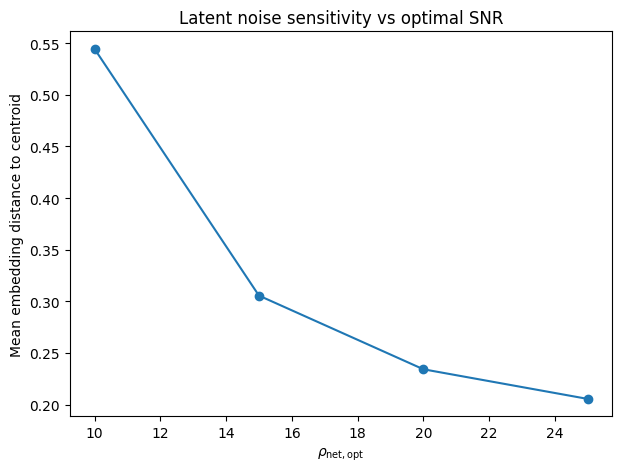

In [74]:
plt.figure(figsize=(7, 5))

plt.plot(
    df_C_embedding["target_snr"],
    df_C_embedding[
        "mean_embedding_distance"
    ],
    marker="o",
)

plt.xlabel(
    r"$\rho_{\rm net,opt}$"
)

plt.ylabel(
    "Mean embedding distance to centroid"
)

plt.title(
    "Latent noise sensitivity vs optimal SNR"
)

plt.show()

# 21. M11.3-C interpretation

M11.3-C studies the dependence of noise-induced prediction variability on the deterministic signal strength.

The physical BBH parameters and the Gaussian-noise realizations are paired across all SNR levels. Only the luminosity distance, and therefore the optimal network SNR, changes.

The principal diagnostic is

$$
\sigma_n(\hat y\mid\rho_{\rm opt}).
$$

A decreasing prediction spread with increasing optimal SNR would demonstrate that weaker signals make the frozen M10 estimator intrinsically more sensitive to the particular noise realization.

Conversely, a weak dependence would indicate that the M10 input normalization and learned representation substantially suppress direct sensitivity to absolute signal strength.

The paired comparison between $\rho_{\rm opt}=10$ and $\rho_{\rm opt}=25$ provides an additional event-level measure of how much the same noise realization changes the inferred parameters when only signal amplitude is modified.

Together, M11.3-A, B and C separate:

$$
\text{controlled signal strength},
$$

$$
\text{realized matched-filter fluctuation},
$$

and

$$
\text{CNN sensitivity to noise}.
$$

# 22. M11.3 — Final conclusion

M11.3 separates three concepts that were previously grouped under the general notion of signal-to-noise ratio:

1. the deterministic **optimal SNR** used to control synthetic signal strength;
2. the **realized matched-filter SNR** produced by a particular noise realization;
3. the sensitivity of the frozen CNN predictor to the full noise realization.

## M11.3-A — Optimal versus realized SNR

For a fixed injected signal,

$$
\rho_{\rm real}
=
\rho_{\rm opt}
+
\Delta\rho.
$$

Under stationary Gaussian noise generated from the same PSD used in the matched-filter inner product, the measured fluctuations are consistent with

$$
E[\Delta\rho]\simeq0
$$

and

$$
\mathrm{Std}(\Delta\rho)\simeq1.
$$

Therefore, controlling the synthetic population through optimal SNR is statistically well defined.

A nominal generation interval

$$
10\le\rho_{\rm opt}\le25
$$

does not imply that every noisy realization has a realized SNR within the same interval.

Samples close to the boundaries can naturally realize below 10 or above 25.

The existing distance-rescaling procedure should therefore remain based on optimal SNR rather than realized SNR.

Conditioning the distance on the realized SNR would make the physical signal amplitude depend on the particular noise realization and would introduce an undesirable selection effect.

## M11.3-B — Noise realization at fixed optimal SNR

Holding the physical event and

$$
\rho_{\rm opt}=15
$$

fixed while changing only the Gaussian-noise realization produces a non-negligible spread in the frozen M10 predictions.

For the controlled event studied here, the prediction variability due only to noise is approximately

$$
\sigma_n(\hat{\mathcal M})\simeq1.8\,M_\odot,
$$

$$
\sigma_n(\hat M_{\rm tot})\simeq4.2\,M_\odot,
$$

and

$$
\sigma_n(\hat\chi_{\rm eff})\simeq0.14.
$$

The CNN embedding also changes appreciably between statistically equivalent noise realizations.

However, these variations are only weakly correlated with

$$
\Delta\rho
=
\rho_{\rm real}-\rho_{\rm opt}.
$$

Therefore realized SNR is not a sufficient scalar description of example difficulty.

The CNN reacts to the full multi-detector temporal and spectral structure of the noise, including components that are not captured by its projection onto the exact injected waveform.

## M11.3-C — Noise sensitivity versus optimal SNR

The same physical BBH event and the same Gaussian-noise realizations were evaluated at

$$
\rho_{\rm opt}
\in
\{10,15,20,25\}.
$$

Only luminosity distance, and therefore signal amplitude, was changed.

The noise-induced prediction spread decreases strongly with increasing optimal SNR.

For chirp mass,

$$
\sigma_n(\hat{\mathcal M})
=
3.86,\ 1.83,\ 1.09,\ 0.82\ M_\odot.
$$

For total mass,

$$
\sigma_n(\hat M_{\rm tot})
=
9.50,\ 4.55,\ 2.99,\ 2.30\ M_\odot.
$$

For effective spin,

$$
\sigma_n(\hat\chi_{\rm eff})
=
0.243,\ 0.139,\ 0.100,\ 0.082.
$$

The latent representation follows the same trend: the mean distance to the SNR-specific embedding centroid decreases approximately as

$$
0.544
\rightarrow
0.306
\rightarrow
0.234
\rightarrow
0.206.
$$

Thus weaker signals are substantially more sensitive to the particular noise realization, both at prediction level and in latent space.

This establishes a direct SNR dependence of predictor robustness.

## Overall interpretation

The M11.3 results support the following picture:

$$
\rho_{\rm opt}
$$

is the appropriate variable for controlling physical signal strength during synthetic generation.

$$
\rho_{\rm real}
$$

is useful diagnostic metadata describing the particular signal-noise realization, but it does not by itself characterize CNN difficulty.

The complete noise realization introduces substantial prediction variability, and this variability increases strongly toward lower optimal SNR.

The predictor therefore exhibits both:

$$
\text{noise-induced variance}
$$

and

$$
\text{event/model-dependent bias}.
$$

Increasing SNR strongly suppresses the former, but does not guarantee elimination of the latter.

Because M11.3-C uses one controlled physical event, the measured numerical biases must not be interpreted as population-level M10 biases. The experiment is intended to establish causal SNR dependence under controlled conditions.

## Decision

No change is made to the optimal-SNR generation policy.

For future M11 datasets, the recommended SNR metadata are:

- per-detector optimal SNR;
- network optimal SNR;
- when feasible, per-detector and network realized matched-filter SNR;
- the explicit distinction between optimal and realized definitions.

Once real off-source strain is introduced, the Gaussian result

$$
\Delta\rho\sim\mathcal N(0,1)
$$

will be revisited as a diagnostic of non-Gaussianity and non-stationarity.

Departures in mean, variance, asymmetry or tail probability will then help separate ideal Gaussian behavior from effects produced by empirical PSD variation and genuine real-detector noise structure.

M11.3 is therefore considered closed.